# Klasifikasi Komentar Judol (Judi Online)

Model untuk mendeteksi komentar spam judol di YouTube menggunakan Machine Learning.

**2 Pendekatan:**
1. TF-IDF + Traditional ML (Logistic Regression, Naive Bayes, Random Forest)
2. LSTM Deep Learning

## 1. Import Libraries

In [20]:
pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.20.0


## 2. Load Dataset

In [22]:
# Load labeled dataset
df = pd.read_csv('../datasets/comments_labeled_final.csv')
print(f'Total data: {len(df)}')
print(f'Kolom: {df.columns.tolist()}')
df.head()

Total data: 79296
Kolom: ['video_id', 'author', 'comment_text', 'published_at', 'like_count', 'is_promo', 'ai_prob', 'label']


,video_id,author,comment_text,published_at,like_count,is_promo,ai_prob,label
0,YZ4N8jH5R_M,@HermanHerman-tp1us,Maaf bang tapi sekarang km udah gak natural ba...,2025-11-15T23:20:20Z,0,False,0.000016,0
1,YZ4N8jH5R_M,@zallesvhan,Kontennya keren! Terus berkarya bang 🙌\r\nSala...,2025-11-14T09:21:34Z,0,False,0.996698,1
2,YZ4N8jH5R_M,@tedivirgiawan9996,Giliran yg lucu waktu nya cepet bngt😢,2025-11-12T16:07:14Z,0,False,0.002775,0
3,YZ4N8jH5R_M,@entah02,Eh ada Pak jalal 😂😂,2025-11-12T12:39:29Z,0,False,0.003958,0
4,YZ4N8jH5R_M,@FandyFandy-u7d,Sekilas anakNya jarwo mirip te ocah yh..tau cM...,2025-11-12T05:44:36Z,0,False,0.000082,0


Distribusi Label:
label
0    75047
1     4249
Name: count, dtype: int64

Persentase Judol: 5.36%


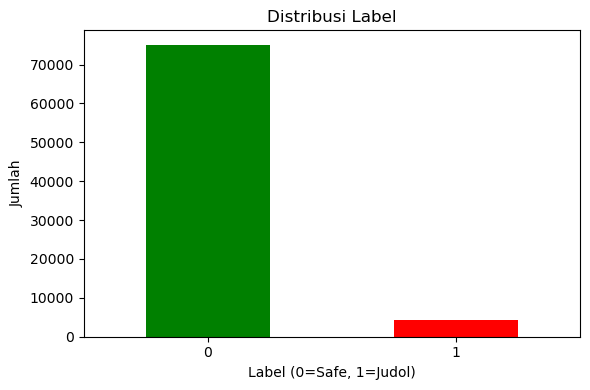

In [23]:
# Cek distribusi label
print('Distribusi Label:')
print(df['label'].value_counts())
print(f"\nPersentase Judol: {df['label'].mean()*100:.2f}%")

# Visualisasi
plt.figure(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribusi Label')
plt.xlabel('Label (0=Safe, 1=Judol)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [24]:
# Drop missing values
df = df.dropna(subset=['comment_text', 'label'])

# Features dan Target
X = df['comment_text'].astype(str)
y = df['label'].astype(int)

print(f'Total samples: {len(X)}')
print(f'Judol (1): {y.sum()}')
print(f'Safe (0): {len(y) - y.sum()}')

Total samples: 79295
Judol (1): 4249
Safe (0): 75046


In [25]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {len(X_train)}')
print(f'Test set: {len(X_test)}')

Training set: 63436
Test set: 15859


---
# PART A: TF-IDF + Traditional ML
---

## 4. Feature Extraction (TF-IDF)

In [26]:
# TF-IDF Vectorizer dengan char_wb untuk obfuscation
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),
    analyzer='char_wb',
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Vocabulary size: {len(tfidf.vocabulary_)}')
print(f'Train shape: {X_train_tfidf.shape}')

Vocabulary size: 10000
Train shape: (63436, 10000)


## 5. Train TF-IDF Models

In [27]:
# Logistic Regression
print('Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f} | F1: {f1_score(y_test, y_pred_lr):.4f}')

Training Logistic Regression...
Accuracy: 0.9821 | F1: 0.8475


In [28]:
# Naive Bayes
print('Training Naive Bayes...')
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred_nb):.4f} | F1: {f1_score(y_test, y_pred_nb):.4f}')

Training Naive Bayes...
Accuracy: 0.9815 | F1: 0.8168


In [29]:
# Random Forest
print('Training Random Forest...')
rf_model = RandomForestClassifier(n_estimators=100, max_depth=50, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} | F1: {f1_score(y_test, y_pred_rf):.4f}')

Training Random Forest...
Accuracy: 0.9753 | F1: 0.7045


## 6. Confusion Matrix - TF-IDF Models

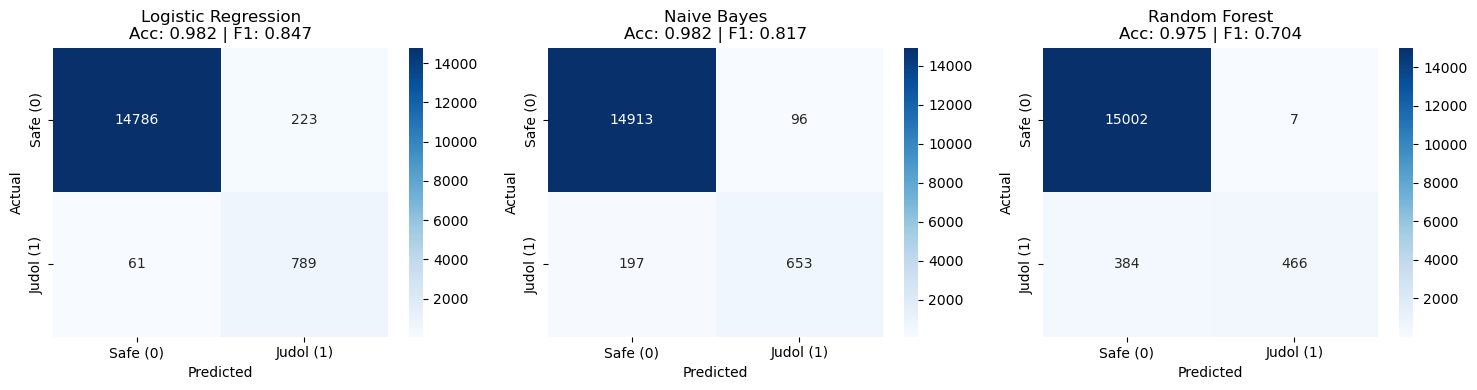

In [30]:
# Plot confusion matrix untuk semua TF-IDF models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_tfidf = [
    ('Logistic Regression', y_pred_lr),
    ('Naive Bayes', y_pred_nb),
    ('Random Forest', y_pred_rf)
]

for ax, (name, y_pred) in zip(axes, models_tfidf):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Safe (0)', 'Judol (1)'],
                yticklabels=['Safe (0)', 'Judol (1)'])
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, y_pred):.3f} | F1: {f1_score(y_test, y_pred):.3f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [31]:
# Classification Report - Best TF-IDF Model
print('=== Classification Report: Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Safe (0)', 'Judol (1)']))

=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

    Safe (0)       1.00      0.99      0.99     15009
   Judol (1)       0.78      0.93      0.85       850

    accuracy                           0.98     15859
   macro avg       0.89      0.96      0.92     15859
weighted avg       0.98      0.98      0.98     15859



---
# PART B: LSTM Deep Learning
---

## 7. Tokenization untuk LSTM

In [32]:
# Hyperparameters
MAX_WORDS = 20000
MAX_LEN = 100
EMBEDDING_DIM = 128

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, char_level=False, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocabulary size: {len(tokenizer.word_index)}')
print(f'Train shape: {X_train_pad.shape}')

Vocabulary size: 67179
Train shape: (63436, 100)


## 8. Build & Train LSTM Model

In [33]:
# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f'Class weights: {class_weight_dict}')

Class weights: {0: np.float64(0.5283075436813964), 1: np.float64(9.331568108267138)}


In [34]:
# Build Bidirectional LSTM model
lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

2025-12-25 19:24:29.915002: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Train with epochs=100 and patience=5
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print(f'\nTraining stopped at epoch: {len(history.history["loss"])}')

Epoch 1/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 254s 267ms/step - accuracy: 0.9091 - loss: 0.2676 - val_accuracy: 0.9645 - val_loss: 0.1159
Epoch 2/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 224s 251ms/step - accuracy: 0.9716 - loss: 0.1014 - val_accuracy: 0.9500 - val_loss: 0.1394
Epoch 3/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 223s 250ms/step - accuracy: 0.9852 - loss: 0.0563 - val_accuracy: 0.9634 - val_loss: 0.1212
Epoch 4/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 226s 253ms/step - accuracy: 0.9896 - loss: 0.0441 - val_accuracy: 0.9803 - val_loss: 0.0861
Epoch 5/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 227s 255ms/step - accuracy: 0.9914 - loss: 0.0355 - val_accuracy: 0.9716 - val_loss: 0.1175
Epoch 6/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 219s 244ms/step - accuracy: 0.9922 - loss: 0.0305 - val_accuracy: 0.9797 - val_loss: 0.0924
Epoch 7/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 228s 255ms/step - accuracy: 0.9926 - loss: 0.0296 - val_accuracy: 0.9655 - val_loss: 0.1479
Epoch 8/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 188s 210ms/step - accuracy: 

## 9. Training Metrics Table (Loss, Accuracy, Val_Loss, Val_Acc)

In [36]:
# Create metrics table
metrics_df = pd.DataFrame({
    'Epoch': range(1, len(history.history['loss']) + 1),
    'Loss': history.history['loss'],
    'Accuracy': history.history['accuracy'],
    'Val_Loss': history.history['val_loss'],
    'Val_Accuracy': history.history['val_accuracy']
})

print('=== LSTM Training Metrics per Epoch ===')
print(metrics_df.to_string(index=False))

# Best epoch
best_epoch = metrics_df['Val_Loss'].idxmin() + 1
print(f'\nBest Epoch (lowest val_loss): {best_epoch}')
print(metrics_df.iloc[best_epoch-1])

=== LSTM Training Metrics per Epoch ===
 Epoch     Loss  Accuracy  Val_Loss  Val_Accuracy
     1 0.267636  0.909094  0.115924      0.964533
     2 0.101422  0.971572  0.139378      0.950032
     3 0.056284  0.985199  0.121175      0.963430
     4 0.044100  0.989561  0.086086      0.980296
     5 0.035479  0.991382  0.117548      0.971627
     6 0.030518  0.992171  0.092376      0.979666
     7 0.029645  0.992591  0.147928      0.965479
     8 0.026200  0.993362  0.155537      0.962484
     9 0.019841  0.996112  0.153371      0.971627

Best Epoch (lowest val_loss): 4
Epoch           4.000000
Loss            0.044100
Accuracy        0.989561
Val_Loss        0.086086
Val_Accuracy    0.980296
Name: 3, dtype: float64


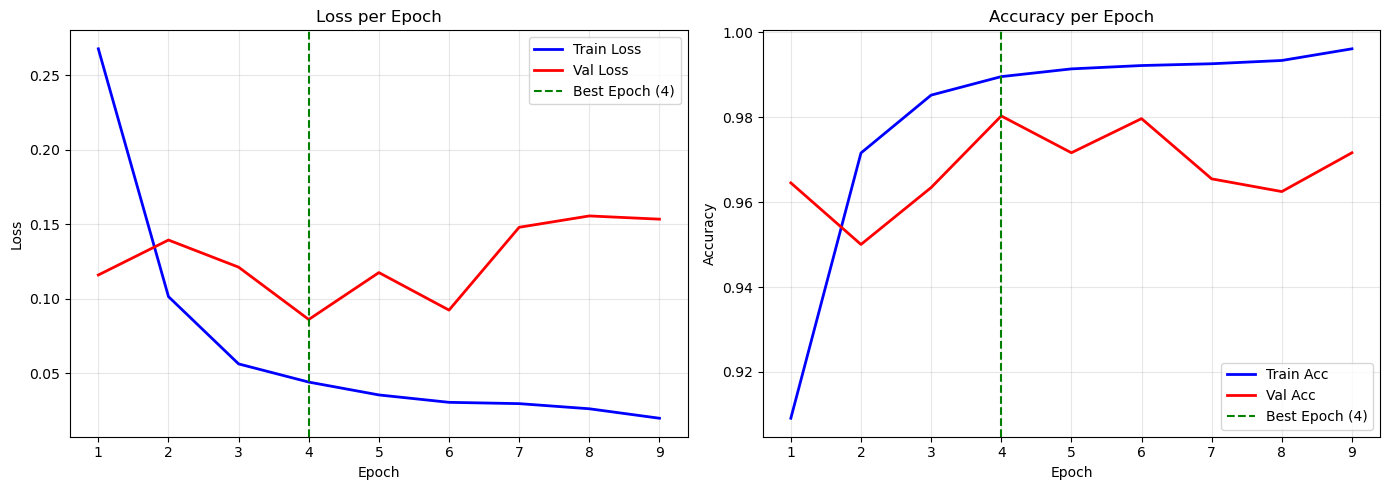

In [37]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(metrics_df['Epoch'], metrics_df['Loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(metrics_df['Epoch'], metrics_df['Val_Loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch, color='g', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(metrics_df['Epoch'], metrics_df['Accuracy'], 'b-', label='Train Acc', linewidth=2)
axes[1].plot(metrics_df['Epoch'], metrics_df['Val_Accuracy'], 'r-', label='Val Acc', linewidth=2)
axes[1].axvline(x=best_epoch, color='g', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Evaluate LSTM & Confusion Matrix

In [38]:
# Predict
y_pred_lstm_prob = lstm_model.predict(X_test_pad)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

print(f'LSTM Accuracy: {accuracy_score(y_test, y_pred_lstm):.4f}')
print(f'LSTM F1-Score: {f1_score(y_test, y_pred_lstm):.4f}')

496/496 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step
LSTM Accuracy: 0.9835
LSTM F1-Score: 0.8496


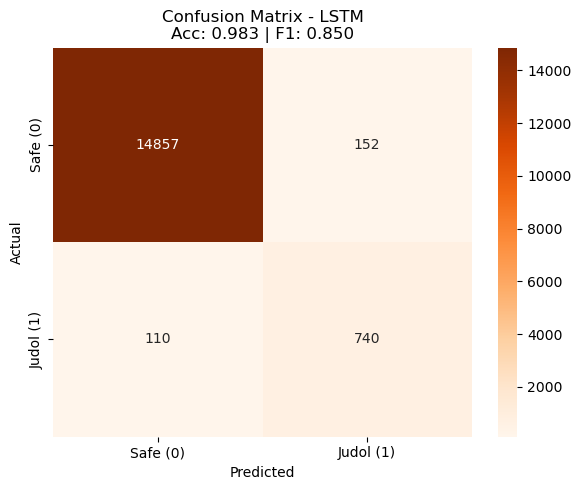


=== Classification Report: LSTM ===
              precision    recall  f1-score   support

    Safe (0)       0.99      0.99      0.99     15009
   Judol (1)       0.83      0.87      0.85       850

    accuracy                           0.98     15859
   macro avg       0.91      0.93      0.92     15859
weighted avg       0.98      0.98      0.98     15859



In [39]:
# Confusion Matrix - LSTM
plt.figure(figsize=(6, 5))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Safe (0)', 'Judol (1)'],
            yticklabels=['Safe (0)', 'Judol (1)'])
plt.title(f'Confusion Matrix - LSTM\nAcc: {accuracy_score(y_test, y_pred_lstm):.3f} | F1: {f1_score(y_test, y_pred_lstm):.3f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('\n=== Classification Report: LSTM ===')
print(classification_report(y_test, y_pred_lstm, target_names=['Safe (0)', 'Judol (1)']))

---
# Comparison: All Models
---

In [40]:
# Compare all models
results = [
    {'Model': 'Logistic Regression', 'Accuracy': accuracy_score(y_test, y_pred_lr), 'F1-Score': f1_score(y_test, y_pred_lr)},
    {'Model': 'Naive Bayes', 'Accuracy': accuracy_score(y_test, y_pred_nb), 'F1-Score': f1_score(y_test, y_pred_nb)},
    {'Model': 'Random Forest', 'Accuracy': accuracy_score(y_test, y_pred_rf), 'F1-Score': f1_score(y_test, y_pred_rf)},
    {'Model': 'Bidirectional LSTM', 'Accuracy': accuracy_score(y_test, y_pred_lstm), 'F1-Score': f1_score(y_test, y_pred_lstm)},
]

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print('\n=== MODEL COMPARISON ===')
print(results_df.to_string(index=False))


=== MODEL COMPARISON ===
              Model  Accuracy  F1-Score
 Bidirectional LSTM  0.983479  0.849598
Logistic Regression  0.982092  0.847476
        Naive Bayes  0.981525  0.816760
      Random Forest  0.975345  0.704460


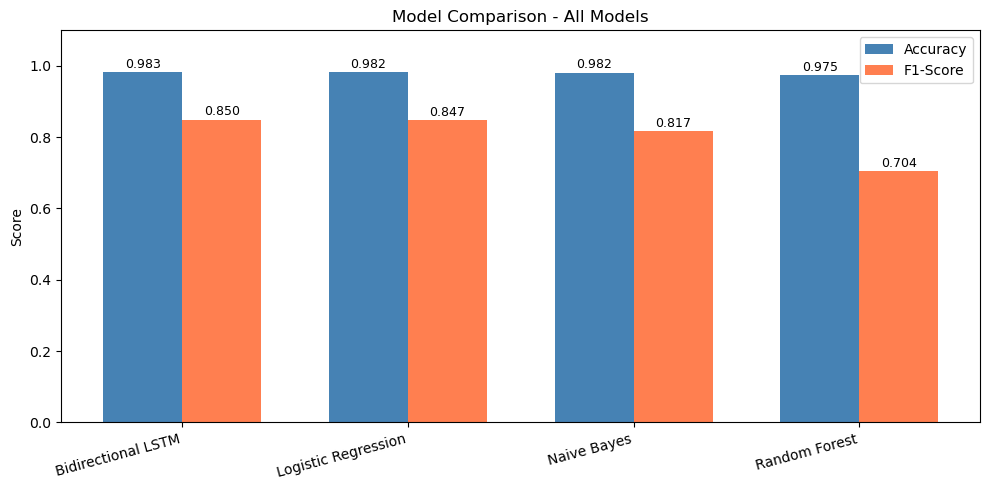

In [41]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Comparison - All Models')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 11. Save Models

In [42]:
import os
os.makedirs('../models', exist_ok=True)

# Save TF-IDF
joblib.dump(lr_model, '../models/judol_logreg_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

# Save LSTM
lstm_model.save('../models/judol_lstm_model.keras')
joblib.dump(tokenizer, '../models/lstm_tokenizer.pkl')

print('All models saved!')

All models saved!


## 12. Test Inference

In [43]:
def predict_tfidf(text):
    X = tfidf.transform([text])
    pred = lr_model.predict(X)[0]
    prob = lr_model.predict_proba(X)[0][1]
    return pred, prob

def predict_lstm(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    prob = lstm_model.predict(pad, verbose=0)[0][0]
    pred = 1 if prob > 0.5 else 0
    return pred, prob

# Test
test_comments = [
    'Video bagus bang, lanjutkan!',
    'Gaskeun join di MINI1221 banyak bonus!',
    'Buruan join di 𝐏𝐀𝐒𝐓𝐄𝟒𝐃 banyak cuan!',
    '2,8rb subs skrng pasti bakalan jutaan subs smangat',
    'Semangat terus kak, kontennya bagus!',
]

print('\n=== PREDICTION TEST ===')
print('-' * 80)
for comment in test_comments:
    pred_tf, prob_tf = predict_tfidf(comment)
    pred_lstm, prob_lstm = predict_lstm(comment)

    label_tf = 'JUDOL' if pred_tf == 1 else 'SAFE'
    label_lstm = 'JUDOL' if pred_lstm == 1 else 'SAFE'

    print(f'Text: {comment[:50]}...')
    print(f'  TF-IDF: [{label_tf}] ({prob_tf:.2%})')
    print(f'  LSTM:   [{label_lstm}] ({prob_lstm:.2%})')
    print()


=== PREDICTION TEST ===
--------------------------------------------------------------------------------
Text: Video bagus bang, lanjutkan!...
  TF-IDF: [SAFE] (37.87%)
  LSTM:   [SAFE] (0.09%)

Text: Gaskeun join di MINI1221 banyak bonus!...
  TF-IDF: [JUDOL] (83.24%)
  LSTM:   [JUDOL] (99.96%)

Text: Buruan join di 𝐏𝐀𝐒𝐓𝐄𝟒𝐃 banyak cuan!...
  TF-IDF: [JUDOL] (99.86%)
  LSTM:   [JUDOL] (99.97%)

Text: 2,8rb subs skrng pasti bakalan jutaan subs smangat...
  TF-IDF: [SAFE] (25.73%)
  LSTM:   [JUDOL] (63.11%)

Text: Semangat terus kak, kontennya bagus!...
  TF-IDF: [SAFE] (38.39%)
  LSTM:   [SAFE] (0.56%)



In [44]:
def predict_ensemble(text):
    # Get probabilities from TF-IDF model
    _, prob_tf = predict_tfidf(text)

    # Get probabilities from LSTM model
    _, prob_lstm = predict_lstm(text)

    # Calculate the weighted average of the probabilities
    ensemble_prob = (0.6 * prob_tf) + (0.4 * prob_lstm)

    # Determine the ensemble's final predicted label
    ensemble_pred = 1 if ensemble_prob > 0.5 else 0

    return ensemble_pred, ensemble_prob

print("Ensemble prediction function 'predict_ensemble' defined with weighted averaging.")

Ensemble prediction function 'predict_ensemble' defined with weighted averaging.


In [45]:
manual_comment = input('Masukkan komentar YouTube Anda: ')

print('\n=== MANUAL COMMENT PREDICTION ===')
print('-' * 80)

pred_tf, prob_tf = predict_tfidf(manual_comment)
pred_lstm, prob_lstm = predict_lstm(manual_comment)
pred_ensemble, prob_ensemble = predict_ensemble(manual_comment) # This now uses weighted average

label_tf = 'JUDOL' if pred_tf == 1 else 'SAFE'
label_lstm = 'JUDOL' if pred_lstm == 1 else 'SAFE'
label_ensemble = 'JUDOL' if pred_ensemble == 1 else 'SAFE'

print(f'Komentar: {manual_comment}')
print(f'  TF-IDF:   [{label_tf}] ({prob_tf:.2%})')
print(f'  LSTM:     [{label_lstm}] ({prob_lstm:.2%})')
print(f'  Ensemble: [{label_ensemble}] ({prob_ensemble:.2%})')

if label_tf != label_lstm or label_tf != label_ensemble or label_lstm != label_ensemble:
    print('  -> Ada perbedaan prediksi antar model!')
else:
    print('  -> Semua model setuju!')


=== MANUAL COMMENT PREDICTION ===
--------------------------------------------------------------------------------
Komentar: Kesimpulan: Lagu "Tarot" adalah eksplorasi tentang bagaimana manusia menghadapi takdir, kepercayaan, dan pencarian makna hidup di tengah kompleksitas kehidupan modern. .Feast ingin mengajak pendengar untuk tidak hanya menerima apa yang ada, tetapi juga mempertanyakan dan merenungkan peran mereka di dunia in
  TF-IDF:   [JUDOL] (52.33%)
  LSTM:     [SAFE] (0.04%)
  Ensemble: [SAFE] (31.41%)
  -> Ada perbedaan prediksi antar model!
